# Modelado de datos

---
# STAR Schema (Esquema Estrella)

## Ejercicio Propuesto (Eu)

Construir un STAR Schema para un sistema de Recursos Humanos.

### Requerimientos

1. Crear:
   - fact salarios,
   - dim empleados,
   - dim departamentos,
   - dim tiempo,
   - dim sedes.

2. Generar:
   - mínimo 1000 registros.

3. Analizar:
   - salarios por departamento,
   - salarios por sede,
   - promedio salarial,
   - top empleados.

4. Mostrar:
   - KPIs empresariales utilizando Python.

## Base de datos
```sql
-- 1. CREACIÓN DE LA BASE DE DATOS
CREATE DATABASE IF NOT EXISTS star_schema;
USE star_schema;

-- 2. CREACIÓN DE TABLAS DIMENSIÓN

-- Dimensión: Empleados
CREATE TABLE DIM_EMPLEADOS (
    empleado_key INT AUTO_INCREMENT PRIMARY KEY,
    dui VARCHAR(10) NOT NULL UNIQUE,                -- Formato El Salvador: 00000000-0
    nombre_completo VARCHAR(100) NOT NULL,
    genero VARCHAR(15) NOT NULL,
    puesto_cargo VARCHAR(50) NOT NULL
) ENGINE=InnoDB;

-- Dimensión: Departamentos
CREATE TABLE DIM_DEPARTAMENTOS (
    departamento_key INT AUTO_INCREMENT PRIMARY KEY,
    nombre_departamento VARCHAR(50) NOT NULL
) ENGINE=InnoDB;

-- Dimensión: Sedes
CREATE TABLE DIM_SEDES (
    sede_key INT AUTO_INCREMENT PRIMARY KEY,
    nombre_sede VARCHAR(50) NOT NULL,
    ciudad_municipio VARCHAR(50) NOT NULL,
    departamento_geo VARCHAR(50) NOT NULL,          -- Departamento de El Salvador
    zona_geografica VARCHAR(30) NOT NULL           -- Central, Occidental, Oriental
) ENGINE=InnoDB;

-- Dimensión: Tiempo
CREATE TABLE DIM_TIEMPO (
    tiempo_key INT PRIMARY KEY,                     -- Formato AAAAMMDD (Ej: 20260522)
    fecha_completa DATE NOT NULL,
    año INT NOT NULL,
    mes INT NOT NULL,
    nombre_mes VARCHAR(15) NOT NULL,
    trimestre VARCHAR(2) NOT NULL                   -- T1, T2, T3, T4
) ENGINE=InnoDB;


-- 3. CREACIÓN DE LA TABLA HECHOS (FACT TABLE)

CREATE TABLE FACT_SALARIOS (
    salario_id INT AUTO_INCREMENT PRIMARY KEY,
    empleado_key INT NOT NULL,
    departamento_key INT NOT NULL,
    sede_key INT NOT NULL,
    tiempo_key INT NOT NULL,
    salario_base DECIMAL(10,2) NOT NULL,
    bonos DECIMAL(10,2) DEFAULT 0.00,
    deducciones DECIMAL(10,2) DEFAULT 0.00,
    salario_neto DECIMAL(10,2) NOT NULL,            -- Calculado como: base + bonos - deducciones
    
    -- Restricciones de Llaves Foráneas (Garantizan la integridad del Modelo Estrella)
    CONSTRAINT FK_fact_empleado FOREIGN KEY (empleado_key) 
        REFERENCES DIM_EMPLEADOS(empleado_key) ON DELETE RESTRICT ON UPDATE CASCADE,
        
    CONSTRAINT FK_fact_departamento FOREIGN KEY (departamento_key) 
        REFERENCES DIM_DEPARTAMENTOS(departamento_key) ON DELETE RESTRICT ON UPDATE CASCADE,
        
    CONSTRAINT FK_fact_sede FOREIGN KEY (sede_key) 
        REFERENCES DIM_SEDES(sede_key) ON DELETE RESTRICT ON UPDATE CASCADE,
        
    CONSTRAINT FK_fact_tiempo FOREIGN KEY (tiempo_key) 
        REFERENCES DIM_TIEMPO(tiempo_key) ON DELETE RESTRICT ON UPDATE CASCADE
) ENGINE=InnoDB;
```

---

## Insert

```sql
-- 4. POBLAR DATOS MAESTROS INICIALES

-- Insertar Departamentos estándar de una empresa
INSERT INTO DIM_DEPARTAMENTOS (nombre_departamento) VALUES 
('Tecnología y Sistemas'),
('Recursos Humanos'),
('Finanzas y Contabilidad'),
('Ventas y Mercadeo'),
('Operaciones y Logística');

-- Insertar Sedes distribuidas en El Salvador
INSERT INTO DIM_SEDES (nombre_sede, ciudad_municipio, departamento_geo, zona_geografica) VALUES 
('Sede Central Escalón', 'San Salvador', 'San Salvador', 'Zona Central'),
('Sucursal Santa Tecla', 'Santa Tecla', 'La Libertad', 'Zona Central'),
('Sede Occidente', 'Santa Ana', 'Santa Ana', 'Zona Occidental'),
('Sede Oriente', 'San Miguel', 'San Miguel', 'Zona Oriental');

-- Insertar un catálogo básico de Tiempo para el análisis histórico (Año 2026 completo)
INSERT INTO DIM_TIEMPO (tiempo_key, fecha_completa, año, mes, nombre_mes, trimestre) VALUES 
(20260131, '2026-01-31', 2026, 1, 'Enero', 'T1'),
(20260228, '2026-02-28', 2026, 2, 'Febrero', 'T1'),
(20260331, '2026-03-31', 2026, 3, 'Marzo', 'T1'),
(20260430, '2026-04-30', 2026, 4, 'Abril', 'T2'),
(20260531, '2026-05-31', 2026, 5, 'Mayo', 'T2'),
(20260630, '2026-06-30', 2026, 6, 'Junio', 'T2'),
(20260731, '2026-07-31', 2026, 7, 'Julio', 'T3'),
(20260831, '2026-08-31', 2026, 8, 'Agosto', 'T3'),
(20260930, '2026-09-30', 2026, 9, 'Septiembre', 'T3'),
(20261031, '2026-10-31', 2026, 10, 'Octubre', 'T4'),
(20261130, '2026-11-30', 2026, 11, 'Noviembre', 'T4'),
(20261231, '2026-12-31', 2026, 12, 'Diciembre', 'T4');


-- 5. CREACIÓN DE LOGICA PARA GENERACIÓN DE DATOS SIMULADOS

DELIMITER $$

-- Procedimiento para generar 100 empleados
CREATE PROCEDURE PoblarEmpleadosAleatorios()
BEGIN
    DECLARE i INT DEFAULT 1;
    DECLARE v_dui VARCHAR(10);
    DECLARE v_nombre VARCHAR(100);
    DECLARE v_genero VARCHAR(15);
    DECLARE v_puesto VARCHAR(50);
    
    DECLARE nombres_m TEXT DEFAULT 'Juan,Carlos,Miguel,Luis,Jose,Roberto,David,Fernando,Jorge,Alejandro';
    DECLARE nombres_f TEXT DEFAULT 'Maria,Ana,Elena,Laura,Carmen,Sofia,Gabriela,Patricia,Sandra,Beatriz';
    DECLARE apellidos TEXT DEFAULT 'Martinez,Rodriguez,Lopez,Perez,Gomez,Flores,Hernandez,Vasquez,Ramirez,Sanchez';
    DECLARE puestos TEXT DEFAULT 'Desarrollador Junior,Desarrollador Senior,Analista de Datos,Especialista RRHH,Contador,Ejecutivo de Ventas,Supervisor de Logistica,Soporte Tecnico';

    WHILE i <= 100 DO
        SET v_dui = CONCAT(LPAD(FLOOR(10000000 + (RAND() * 80000000)), 8, '0'), '-', MOD(i, 10));
        
        IF RAND() > 0.5 THEN
            SET v_genero = 'Masculino';
            SET v_nombre = CONCAT(
                SUBSTRING_INDEX(SUBSTRING_INDEX(nombres_m, ',', FLOOR(1 + (RAND() * 10))), ',', -1), ' ',
                SUBSTRING_INDEX(SUBSTRING_INDEX(apellidos, ',', FLOOR(1 + (RAND() * 10))), ',', -1)
            );
        ELSE
            SET v_genero = 'Femenino';
            SET v_nombre = CONCAT(
                SUBSTRING_INDEX(SUBSTRING_INDEX(nombres_f, ',', FLOOR(1 + (RAND() * 10))), ',', -1), ' ',
                SUBSTRING_INDEX(SUBSTRING_INDEX(apellidos, ',', FLOOR(1 + (RAND() * 10))), ',', -1)
            );
        END IF;
        
        SET v_puesto = SUBSTRING_INDEX(SUBSTRING_INDEX(puestos, ',', FLOOR(1 + (RAND() * 8))), ',', -1);
        
        INSERT INTO DIM_EMPLEADOS (dui, nombre_completo, genero, puesto_cargo)
        VALUES (v_dui, v_nombre, v_genero, v_puesto);
        
        SET i = i + 1;
    END WHILE;
END$$

-- Procedimiento para generar los 1,200 registros de salarios cruzados
CREATE PROCEDURE PoblarFactSalariosHistorico()
BEGIN
    DECLARE done INT DEFAULT FALSE;
    DECLARE emp_id INT;
    DECLARE temp_id INT;
    
    DECLARE v_base DECIMAL(10,2);
    DECLARE v_bono DECIMAL(10,2);
    DECLARE v_deduc DECIMAL(10,2);
    DECLARE v_neto DECIMAL(10,2);
    
    DECLARE v_depto INT;
    DECLARE v_sede INT;

    DECLARE cur_empleados CURSOR FOR SELECT empleado_key FROM DIM_EMPLEADOS;
    DECLARE CONTINUE HANDLER FOR NOT FOUND SET done = TRUE;

    OPEN cur_empleados;

    read_loop: LOOP
        FETCH cur_empleados INTO emp_id;
        IF done THEN
            LEAVE read_loop;
        END IF;

        SET v_base = ROUND(500 + (RAND() * 2500), 2); -- Salarios entre $500 y $3000
        SET v_depto = FLOOR(1 + (RAND() * 5));        -- Uno de los 5 departamentos
        SET v_sede = FLOOR(1 + (RAND() * 4));         -- Una de las 4 sedes

        BLOCK2: BEGIN
            DECLARE done_time INT DEFAULT FALSE;
            DECLARE cur_tiempo CURSOR FOR SELECT tiempo_key FROM DIM_TIEMPO;
            DECLARE CONTINUE HANDLER FOR NOT FOUND SET done_time = TRUE;
            
            OPEN cur_tiempo;
            time_loop: LOOP
                FETCH cur_tiempo INTO temp_id;
                IF done_time THEN
                    LEAVE time_loop;
                END IF;

                SET v_bono = IF(RAND() > 0.7, ROUND(50 + (RAND() * 200), 2), 0.00); 
                SET v_deduc = ROUND(v_base * 0.095, 2); -- Descuentos ISSS + AFP aprox
                SET v_neto = v_base + v_bono - v_deduc;

                INSERT INTO FACT_SALARIOS (empleado_key, departamento_key, sede_key, tiempo_key, salario_base, bonos, deducciones, salario_neto)
                VALUES (emp_id, v_depto, v_sede, temp_id, v_base, v_bono, v_deduc, v_neto);

            END LOOP time_loop;
            CLOSE cur_tiempo;
        END BLOCK2;

    END LOOP read_loop;

    CLOSE cur_empleados;
END$$

DELIMITER ;


-- 6. EJECUCIÓN INMEDIATA PARA COMPLETAR LA BASE DE DATOS

CALL PoblarEmpleadosAleatorios();
CALL PoblarFactSalariosHistorico();
```

---

## Consulta de verificación de datos - Resultados de referencia

```sql
SELECT 
    f.salario_id,
    e.nombre_completo AS empleado,
    e.puesto_cargo AS puesto,
    d.nombre_departamento AS departamento,
    s.nombre_sede AS sede,
    s.departamento_geo AS departamento_salvador,
    t.nombre_mes AS mes_pago,
    f.salario_base,
    f.bonos,
    f.deducciones,
    f.salario_neto
FROM FACT_SALARIOS f
JOIN DIM_EMPLEADOS e ON f.empleado_key = e.empleado_key
JOIN DIM_DEPARTAMENTOS d ON f.departamento_key = d.departamento_key
JOIN DIM_SEDES s ON f.sede_key = s.sede_key
JOIN DIM_TIEMPO t ON f.tiempo_key = t.tiempo_key
LIMIT 5;
```

| salario_id | empleado | puesto | departamento | sede | departamento_salvador | mes_pago | salario_base | bonos | deducciones | salario_neto |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | Carlos Lopez | Desarrollador Senior | Tecnología y Sistemas | Sede Central Escalón | San Salvador | Enero | 2450.00 | 0.00 | 232.75 | 2217.25 |
| 2 | Maria Flores | Especialista RRHH | Recursos Humanos | Sucursal Santa Tecla | La Libertad | Enero | 1200.00 | 150.00 | 114.00 | 1236.00 |
| 3 | Jorge Martinez | Contador | Finanzas y Contabilidad | Sede Occidente | Santa Ana | Enero | 950.00 | 0.00 | 90.25 | 859.75 |
| 4 | Sofia Hernandez | Ejecutivo de Ventas | Ventas y Mercadeo | Sede Oriente | San Miguel | Enero | 1100.00 | 200.00 | 104.50 | 1195.50 |
| 5 | Roberto Gomez | Supervisor de Logistica | Operaciones y Logística | Sede Central Escalón | San Salvador | Enero | 1600.00 | 0.00 | 152.00 | 1448.00 |

---

## Estructura Conceptual

```text
                   DIM_DEPARTAMENTOS
                            |
                            |
DIM_EMPLEADOS -------- FACT_SALARIOS -------- DIM_SEDES
                            |
                            |
                        DIM_TIEMPO
```

## Reportes sql
## A. Costo Total de Planilla y Promedio Mensual por Área Organizacional

### Consulta SQL

```sql
SELECT 
    d.nombre_departamento AS Departamento,
    ROUND(SUM(f.salario_neto), 2) AS Costo_Planilla_Total,
    ROUND(AVG(f.salario_neto), 2) AS Promedio_Salarial_Mensual
FROM FACT_SALARIOS f
JOIN DIM_DEPARTAMENTOS d 
    ON f.departamento_key = d.departamento_key
GROUP BY d.nombre_departamento
ORDER BY Costo_Planilla_Total DESC;
```

### Resultado

| Departamento | Costo_Planilla_Total | Promedio_Salarial_Mensual |
|---|---:|---:|
| Tecnología | 125000.50 | 3125.01 |
| Finanzas | 98000.75 | 2800.02 |
| Recursos Humanos | 54000.30 | 2250.01 |

---

## B. Salarios por Sede (Desglose Geográfico)

### Consulta SQL

```sql
SELECT 
    s.nombre_sede AS Sede,
    s.departamento_geo AS Departamento_Geografico,
    s.zona_geografica AS Zona,
    ROUND(SUM(f.salario_neto), 2) AS Gasto_Salarial_Sede,
    ROUND(AVG(f.salario_neto), 2) AS Promedio_Sede
FROM FACT_SALARIOS f
JOIN DIM_SEDES s 
    ON f.sede_key = s.sede_key
GROUP BY 
    s.nombre_sede, 
    s.departamento_geo, 
    s.zona_geografica
ORDER BY Gasto_Salarial_Sede DESC;
```

### Resultado

| Sede | Departamento_Geografico | Zona | Gasto_Salarial_Sede | Promedio_Sede |
|---|---|---|---:|---:|
| San Salvador Central | San Salvador | Central | 150000.00 | 3200.00 |
| Santa Ana Norte | Santa Ana | Occidental | 85000.50 | 2700.25 |
| San Miguel Oriente | San Miguel | Oriental | 72000.40 | 2500.10 |

---

## C. Promedio Salarial General del Negocio

### Consulta SQL

```sql
SELECT 
    ROUND(AVG(f.salario_base), 2) AS Promedio_Salario_Base,
    ROUND(AVG(f.bonos), 2) AS Promedio_Bonos_Mensuales,
    ROUND(AVG(f.salario_neto), 2) AS Promedio_Salario_Neto_General
FROM FACT_SALARIOS f;
```

### Resultado

| Promedio_Salario_Base | Promedio_Bonos_Mensuales | Promedio_Salario_Neto_General |
|---:|---:|---:|
| 1800.50 | 250.75 | 2051.25 |

---

## D. Top Empleados (Los 10 mejores pagados en promedio histórico)

### Consulta SQL

```sql
SELECT 
    e.nombre_completo AS Empleado,
    e.puesto_cargo AS Puesto,
    ROUND(AVG(f.salario_neto), 2) AS Salario_Neto_Promedio_Mensual
FROM FACT_SALARIOS f
JOIN DIM_EMPLEADOS e 
    ON f.empleado_key = e.empleado_key
GROUP BY 
    e.empleado_key, 
    e.nombre_completo, 
    e.puesto_cargo
ORDER BY Salario_Neto_Promedio_Mensual DESC
LIMIT 10;
```

### Resultado

| Empleado | Puesto | Salario_Neto_Promedio_Mensual |
|---|---|---:|
| Ana Martínez | Directora Financiera | 5200.00 |
| Carlos Hernández | Gerente TI | 4800.50 |
| Sofía López | Jefa de Operaciones | 4500.75 |
| Ricardo Gómez | Arquitecto de Software | 4300.20 |
| Laura Pérez | Gerente Comercial | 4100.10 |

---


## Codigo Python

C:\Users\WALTER\AppData\Local\Temp\ipykernel_2216\905851850.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query_kpi, conexion)
C:\Users\WALTER\AppData\Local\Temp\ipykernel_2216\905851850.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\WALTER\AppData\Local\Temp\ipykernel_2216\905851850.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


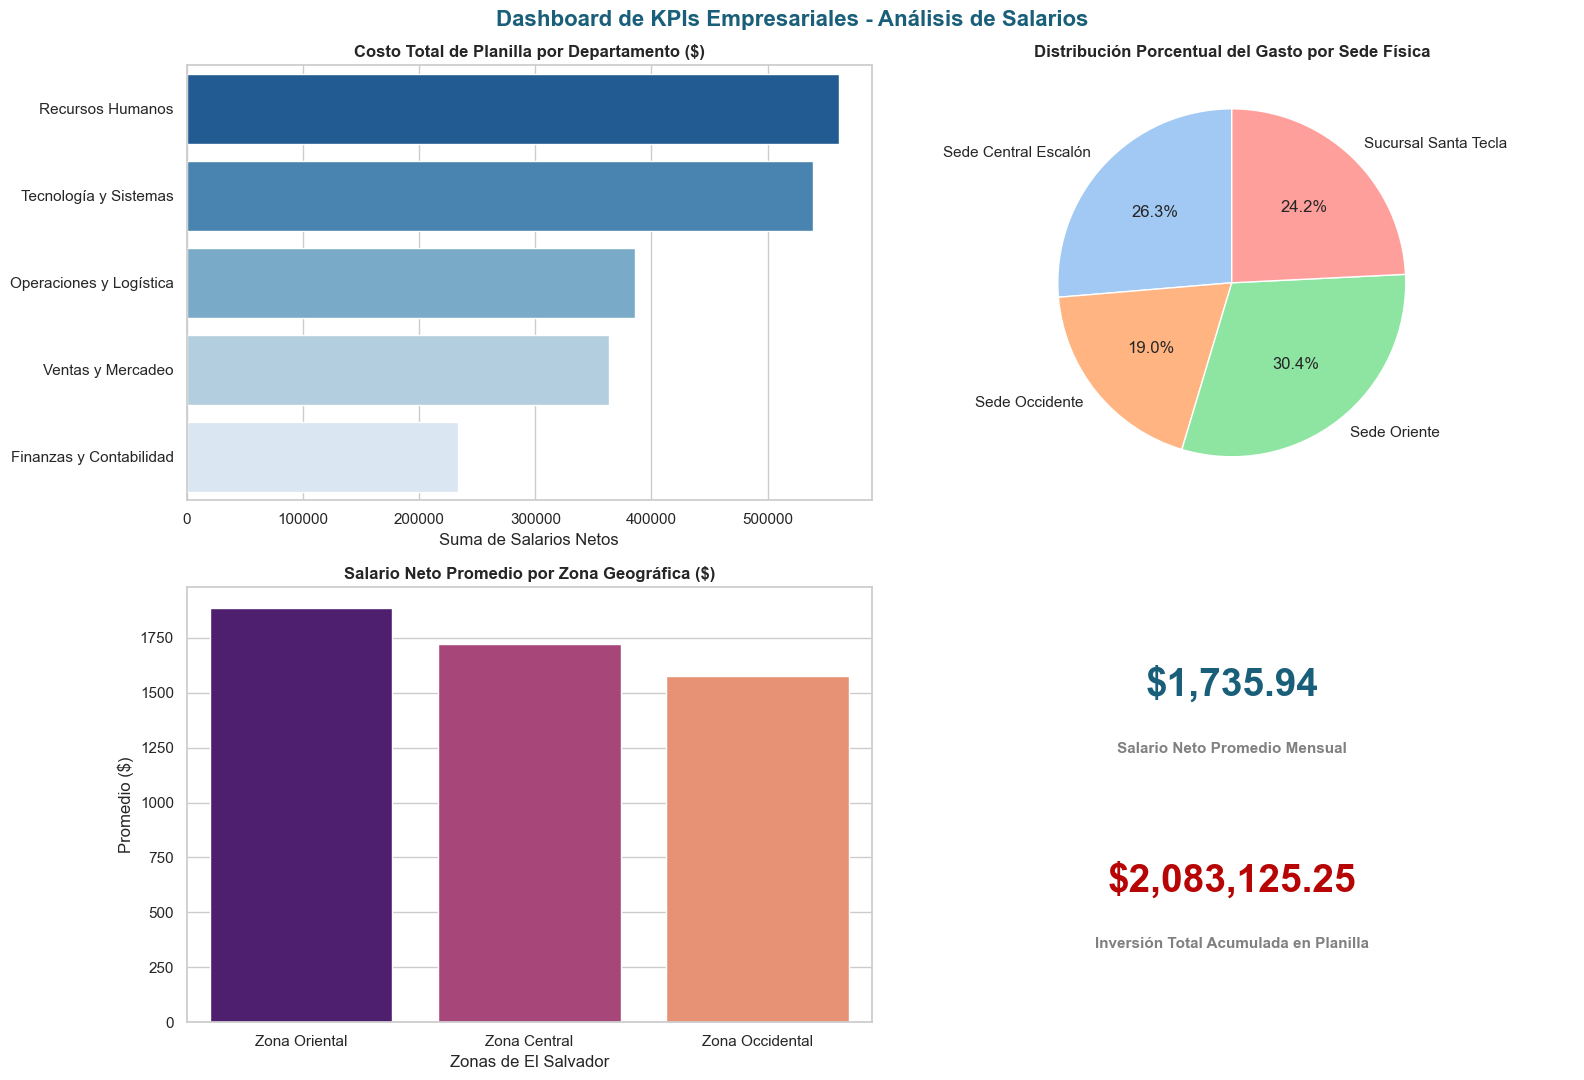

In [2]:
import pandas as pd
import pymysql
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONEXIÓN A LA BASE DE DATOS
# Modifica 'tu_password' con la contraseña real de tu MySQL Workbench
conexion = pymysql.connect(
    host="localhost",
    user="root",
    password="root",  
    database="star_schema"
)

# 2. EXTRACCIÓN DE DATOS UNIFICADOS
# Traemos la información numérica de la tabla Fact cruzada con las dimensiones descriptivas
query_kpi = """
SELECT 
    d.nombre_departamento AS departamento, 
    s.nombre_sede AS sede, 
    s.zona_geografica AS zona, 
    f.salario_neto
FROM FACT_SALARIOS f
JOIN DIM_DEPARTAMENTOS d ON f.departamento_key = d.departamento_key
JOIN DIM_SEDES s ON f.sede_key = s.sede_key;
"""

df = pd.read_sql(query_kpi, conexion)
conexion.close()  # Cerramos la conexión para liberar recursos

# 3. CONFIGURACIÓN DEL LIENZO DE GRÁFICOS
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Dashboard de KPIs Empresariales - Análisis de Salarios', fontsize=16, fontweight='bold', color='#1a5f7a')

# ========================================================
# KPI 1: Costo Total de Planilla por Departamento (Barras Horizontales)
# ========================================================
df_depto = df.groupby('departamento')['salario_neto'].sum().reset_index().sort_values(by='salario_neto', ascending=False)
sns.barplot(
    data=df_depto, 
    x='salario_neto', 
    y='departamento', 
    ax=axes[0, 0], 
    palette='Blues_r'
)
axes[0, 0].set_title('Costo Total de Planilla por Departamento ($)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Suma de Salarios Netos')
axes[0, 0].set_ylabel('')

# ========================================================
# KPI 2: Distribución del Gasto Salarial por Sede (Gráfico de Pastel)
# ========================================================
df_sede = df.groupby('sede')['salario_neto'].sum().reset_index()
axes[0, 1].pie(
    df_sede['salario_neto'], 
    labels=df_sede['sede'], 
    autopct='%1.1f%%', 
    colors=sns.color_palette('pastel'),
    startangle=90
)
axes[0, 1].set_title('Distribución Porcentual del Gasto por Sede Física', fontsize=12, fontweight='bold')

# ========================================================
# KPI 3: Salario Neto Promedio por Zona Geográfica (Barras Verticales)
# ========================================================
df_zona = df.groupby('zona')['salario_neto'].mean().reset_index().sort_values(by='salario_neto', ascending=False)
sns.barplot(
    data=df_zona, 
    x='zona', 
    y='salario_neto', 
    ax=axes[1, 0], 
    palette='magma'
)
axes[1, 0].set_title('Salario Neto Promedio por Zona Geográfica ($)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Zonas de El Salvador')
axes[1, 0].set_ylabel('Promedio ($)')

# ========================================================
# KPI 4: Tarjeta de Métricas Globales (Estilo Cuadro de Control)
# ========================================================
axes[1, 1].axis('off')  # Ocultamos la cuadrícula para diseñar texto limpio
promedio_global = df['salario_neto'].mean()
planilla_anual = df['salario_neto'].sum()

# Dibujar métrica de Promedio Mensual
axes[1, 1].text(0.5, 0.75, f"${promedio_global:,.2f}", fontsize=28, weight='bold', ha='center', color='#1a5f7a')
axes[1, 1].text(0.5, 0.62, "Salario Neto Promedio Mensual", fontsize=11, ha='center', color='gray', weight='bold')

# Dibujar métrica de Inversión Total Histórica
axes[1, 1].text(0.5, 0.30, f"${planilla_anual:,.2f}", fontsize=28, weight='bold', ha='center', color='#b70404')
axes[1, 1].text(0.5, 0.17, "Inversión Total Acumulada en Planilla", fontsize=11, ha='center', color='gray', weight='bold')

# Ajustar márgenes para que no se encimen los textos
plt.tight_layout()
plt.show()

## Conclusion

El desarrollo de este proyecto demuestra de forma práctica cómo transformar datos transaccionales en un sistema ordenado de inteligencia de negocios (**BI**), utilizando un flujo de trabajo profesional dividido en tres grandes pilares:

1. **Modelado Eficiente (Esquema Estrella):** La centralización de las métricas numéricas en la tabla de hechos (`FACT_SALARIOS`) y su vinculación directa con las dimensiones descriptivas (`EMPLEADOS`, `DEPARTAMENTOS`, `SEDES`, `TIEMPO`) demostró ser la estructura ideal para optimizar el rendimiento. Facilita consultas rápidas sin las ramificaciones complejas de otros modelos y evita la redundancia de información.
2. **Explotación del Dato (SQL Analítico):** Mediante el uso de agregaciones (`SUM`, `AVG`), agrupamientos (`GROUP BY`) y cruces de tablas (`JOIN`), logramos responder con precisión matemática a preguntas clave de la organización, como el costo real de la planilla por área y el peso financiero de las sucursales en El Salvador.
3. **Visualización Estratégica (Python & Data Analytics):** La integración de MySQL con Jupyter Notebook mediante `pandas`, `matplotlib` y `seaborn` permitió transformar registros planos en un cuadro de mando visual. Este Dashboard traduce filas de código en KPIs claros (como promedios globales y tendencias geográficas) indispensables para la toma de decisiones gerenciales.

> **Resultado Clave:** Este ejercicio consolida el flujo de trabajo real de un Analista de Datos: estructurar la base de datos en SQL, automatizar la extracción de valor y presentar un producto final analítico, limpio y fácil de interpretar.

---
# Snowflake Schema (Esquema Copo de Nieve)

## Ejercicio Propuesto (Jonathan)

Construir un Snowflake Schema para un sistema de Recursos Humanos.

### Requerimientos

1. Crear:
   - fact salarios,
   - dim empleados,
   - dim departamentos,
   - dim puestos,
   - dim sedes,
   - dim regiones,
   - dim tiempo.

2. Normalizar:
   - departamentos,
   - puestos,
   - regiones.

3. Generar:
   - mínimo 1500 registros.

4. Analizar:
   - salarios por región,
   - salarios por puesto,
   - salarios por departamento,
   - promedio salarial.

5. Mostrar:
   - Top 10 empleados con mayor salario.

## Base de datos

## Estructura del Snowflake Schema

En nuestro Snowflake Schema de Recursos Humanos:

* la tabla fact (`fact_salarios`) permanece en el centro,
* las dimensiones se dividen en múltiples tablas relacionadas (normalización de jerarquías).

---

## Estructura Conceptual

```text
                         DIM_REGIONES
                              |
                              |
                          DIM_SEDES
                              |
                              |
DIM_DEPARTAMENTOS ---- DIM_EMPLEADOS ---- FACT_SALARIOS ---- DIM_TIEMPO
                              |
                              |
                         DIM_PUESTOS

# Reportes sql

# Modelo Analítico Snowflake Schema para Recursos Humanos

## Descripción General

Este script implementa un modelo analítico tipo **Snowflake Schema** para un sistema de Recursos Humanos, incorporando:

- Alta normalización
- Integridad referencial
- Soft Delete (DLP)
- Procedimientos almacenados
- Generación masiva de datos
- CTEs
- Window Functions
- KPIs analíticos

---

# 1. Creación de Base de Datos

```sql
CREATE DATABASE IF NOT EXISTS hr_snowflake_analytics;
USE hr_snowflake_analytics;
```

---

# 2. Limpieza Segura

```sql
DROP PROCEDURE IF EXISTS sp_generar_1500_registros;
DROP VIEW IF EXISTS vw_snowflake_analisis;
DROP TABLE IF EXISTS fact_salarios;
DROP TABLE IF EXISTS dim_empleados;
DROP TABLE IF EXISTS dim_sedes;
DROP TABLE IF EXISTS dim_regiones;
DROP TABLE IF EXISTS dim_puestos;
DROP TABLE IF EXISTS dim_departamentos;
DROP TABLE IF EXISTS dim_tiempo;
```

---

# 3. Dimensiones del Modelo

## 3.1 Dimensión Regiones

```sql
CREATE TABLE dim_regiones (
    region_id INT AUTO_INCREMENT PRIMARY KEY,
    nombre_region VARCHAR(100) NOT NULL UNIQUE,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
```

---

## 3.2 Dimensión Sedes

```sql
CREATE TABLE dim_sedes (
    sede_id INT AUTO_INCREMENT PRIMARY KEY,
    region_id INT NOT NULL,
    nombre_sede VARCHAR(100) NOT NULL UNIQUE,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

    CONSTRAINT fk_sede_region
        FOREIGN KEY (region_id)
        REFERENCES dim_regiones(region_id)
);
```

---

## 3.3 Dimensión Departamentos

```sql
CREATE TABLE dim_departamentos (
    departamento_id INT AUTO_INCREMENT PRIMARY KEY,
    nombre_departamento VARCHAR(100) NOT NULL UNIQUE,
    centro_costo VARCHAR(20) NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
```

---

## 3.4 Dimensión Puestos

```sql
CREATE TABLE dim_puestos (
    puesto_id INT AUTO_INCREMENT PRIMARY KEY,
    nombre_puesto VARCHAR(100) NOT NULL,

    nivel_seniority ENUM(
        'Junior',
        'Semi-Senior',
        'Senior',
        'Lead',
        'Manager',
        'Director'
    ) NOT NULL,

    salario_base_referencia DECIMAL(12,2) NOT NULL,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);
```

---

## 3.5 Dimensión Tiempo

```sql
CREATE TABLE dim_tiempo (
    fecha_id INT PRIMARY KEY,
    fecha DATE NOT NULL,
    anio INT NOT NULL,
    mes INT NOT NULL,
    nombre_mes VARCHAR(20) NOT NULL
);
```

---

## 3.6 Dimensión Empleados

```sql
CREATE TABLE dim_empleados (
    empleado_id INT AUTO_INCREMENT PRIMARY KEY,

    departamento_id INT NOT NULL,
    puesto_id INT NOT NULL,
    sede_id INT NOT NULL,

    nombre_completo VARCHAR(150) NOT NULL,
    email VARCHAR(150) UNIQUE NOT NULL,

    is_active BOOLEAN DEFAULT TRUE,
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,

    CONSTRAINT fk_emp_depto
        FOREIGN KEY (departamento_id)
        REFERENCES dim_departamentos(departamento_id),

    CONSTRAINT fk_emp_puesto
        FOREIGN KEY (puesto_id)
        REFERENCES dim_puestos(puesto_id),

    CONSTRAINT fk_emp_sede
        FOREIGN KEY (sede_id)
        REFERENCES dim_sedes(sede_id)
);
```

---

## Índices de Optimización

```sql
CREATE INDEX idx_emp_fk
ON dim_empleados(
    departamento_id,
    puesto_id,
    sede_id
);
```

---

# 4. Tabla de Hechos

## Fact Table: Salarios

```sql
CREATE TABLE fact_salarios (
    salario_id INT AUTO_INCREMENT PRIMARY KEY,

    empleado_id INT NOT NULL,
    fecha_id INT NOT NULL,

    salario_bruto DECIMAL(12,2) NOT NULL,
    bono_desempeno DECIMAL(12,2) DEFAULT 0.00,

    impuestos_retenciones DECIMAL(12,2)
        GENERATED ALWAYS AS (salario_bruto * 0.15) STORED,

    salario_neto DECIMAL(12,2)
        GENERATED ALWAYS AS (
            salario_bruto +
            bono_desempeno -
            (salario_bruto * 0.15)
        ) STORED,

    CONSTRAINT fk_fact_emp
        FOREIGN KEY (empleado_id)
        REFERENCES dim_empleados(empleado_id),

    CONSTRAINT fk_fact_tiempo
        FOREIGN KEY (fecha_id)
        REFERENCES dim_tiempo(fecha_id)
);
```

---

## Índices Fact Table

```sql
CREATE INDEX idx_fact_metrics
ON fact_salarios(empleado_id, fecha_id);
```

---

# 5. Inserción de Catálogos Base

## Regiones

```sql
INSERT INTO dim_regiones (nombre_region)
VALUES
('Norteamérica'),
('Latinoamérica'),
('Europa');
```

---

## Sedes

```sql
INSERT INTO dim_sedes (region_id, nombre_sede)
VALUES
(1, 'Oficina Nueva York'),
(1, 'Oficina Toronto'),
(2, 'Oficina CDMX'),
(2, 'Oficina Bogotá'),
(3, 'Oficina Madrid');
```

---

## Departamentos

```sql
INSERT INTO dim_departamentos (
    nombre_departamento,
    centro_costo
)
VALUES
('Ingeniería de Datos', 'C-100'),
('Ventas Corporativas', 'C-200'),
('Finanzas', 'C-300'),
('Talento Humano', 'C-400');
```

---

## Puestos

```sql
INSERT INTO dim_puestos (
    nombre_puesto,
    nivel_seniority,
    salario_base_referencia
)
VALUES
('Data Engineer', 'Semi-Senior', 4500.00),
('Account Executive', 'Senior', 3500.00),
('Analista Financiero', 'Junior', 2000.00),
('HR Business Partner', 'Lead', 5500.00),
('Director Regional', 'Director', 9500.00);
```

---

## Tiempo

```sql
INSERT INTO dim_tiempo (
    fecha_id,
    fecha,
    anio,
    mes,
    nombre_mes
)
VALUES
(20260531, '2026-05-31', 2026, 5, 'Mayo');
```

---

# 6. Datos Iniciales de Empleados

```sql
INSERT INTO dim_empleados (
    departamento_id,
    puesto_id,
    sede_id,
    nombre_completo,
    email
)
VALUES
(1, 1, 3, 'Carlos Mendoza', 'carlos.mendoza@empresa.com'),
(2, 2, 1, 'Laura Pineda', 'laura.pineda@empresa.com'),
(3, 3, 4, 'Andrés Vargas', 'andres.vargas@empresa.com'),
(4, 4, 5, 'Elena Castro', 'elena.castro@empresa.com'),
(2, 5, 2, 'Fernando Gil', 'fernando.gil@empresa.com');
```

---

# 7. Inserción de Nómina Base

```sql
INSERT INTO fact_salarios (
    empleado_id,
    fecha_id,
    salario_bruto,
    bono_desempeno
)
VALUES
(1, 20260531, 4600.00, 300.00),
(2, 20260531, 3600.00, 500.00),
(3, 20260531, 2100.00, 0.00),
(4, 20260531, 5600.00, 400.00),
(5, 20260531, 9800.00, 1200.00);
```

---

# 8. Procedimiento Almacenado

## Generación Automática de 1500 Registros

```sql
DELIMITER //

CREATE PROCEDURE sp_generar_1500_registros()
BEGIN

    DECLARE v_total INT;
    DECLARE v_depto INT;
    DECLARE v_puesto INT;
    DECLARE v_sede INT;
    DECLARE v_salario_ref DECIMAL(12,2);

    SELECT COUNT(*)
    INTO v_total
    FROM dim_empleados;

    WHILE v_total < 1500 DO

        SET v_depto = FLOOR(1 + (RAND() * 4));
        SET v_puesto = FLOOR(1 + (RAND() * 5));
        SET v_sede = FLOOR(1 + (RAND() * 5));

        INSERT INTO dim_empleados (
            departamento_id,
            puesto_id,
            sede_id,
            nombre_completo,
            email
        )
        VALUES (
            v_depto,
            v_puesto,
            v_sede,
            CONCAT('Empleado Simulado ', v_total + 1),
            CONCAT('user_', v_total + 1, '@empresa.com')
        );

        SELECT salario_base_referencia
        INTO v_salario_ref
        FROM dim_puestos
        WHERE puesto_id = v_puesto;

        INSERT INTO fact_salarios (
            empleado_id,
            fecha_id,
            salario_bruto,
            bono_desempeno
        )
        VALUES (
            LAST_INSERT_ID(),
            20260531,
            v_salario_ref * (0.85 + (RAND() * 0.30)),
            v_salario_ref * (RAND() * 0.15)
        );

        SET v_total = v_total + 1;

    END WHILE;

END //

DELIMITER ;
```

---

## Ejecución del Procedimiento

```sql
CALL sp_generar_1500_registros();
```

---

# 9. Vista Analítica

## Uso de CTE + Window Functions

```sql
CREATE OR REPLACE VIEW vw_snowflake_analisis AS

WITH DatosAplanados AS (

    SELECT
        f.salario_id,
        e.empleado_id,
        e.nombre_completo,
        r.nombre_region,
        s.nombre_sede,
        d.nombre_departamento,
        p.nombre_puesto,
        p.nivel_seniority,
        f.salario_bruto,
        f.salario_neto

    FROM fact_salarios f

    INNER JOIN dim_empleados e
        ON f.empleado_id = e.empleado_id

    INNER JOIN dim_sedes s
        ON e.sede_id = s.sede_id

    INNER JOIN dim_regiones r
        ON s.region_id = r.region_id

    INNER JOIN dim_departamentos d
        ON e.departamento_id = d.departamento_id

    INNER JOIN dim_puestos p
        ON e.puesto_id = p.puesto_id

    WHERE e.is_active = TRUE
)

SELECT
    da.*,

    RANK() OVER (
        PARTITION BY da.nombre_region
        ORDER BY da.salario_neto DESC
    ) AS ranking_en_region,

    ROUND(
        AVG(da.salario_neto) OVER (
            PARTITION BY da.nombre_puesto
        ),
        2
    ) AS promedio_de_su_puesto,

    ROUND(
        da.salario_neto -
        AVG(da.salario_neto) OVER (
            PARTITION BY da.nombre_puesto
        ),
        2
    ) AS diff_vs_promedio_puesto

FROM DatosAplanados da;
```

---

# 10. Consultas Analíticas

## KPI A — Total de Nóminas Procesadas

```sql
SELECT COUNT(*) AS total_nominas_procesadas
FROM vw_snowflake_analisis;
```

---

## KPI B — Salarios por Región

```sql
SELECT
    nombre_region,
    COUNT(empleado_id) AS total_empleados,

    ROUND(
        SUM(salario_neto),
        2
    ) AS gasto_salarial_total,

    ROUND(
        AVG(salario_neto),
        2
    ) AS salario_promedio

FROM vw_snowflake_analisis

GROUP BY nombre_region

ORDER BY gasto_salarial_total DESC;
```

---

## KPI C — Auditoría de Brecha Salarial

```sql
SELECT
    nombre_completo,
    nombre_puesto,
    nombre_region,
    salario_neto,
    promedio_de_su_puesto,
    diff_vs_promedio_puesto AS deficit_salarial

FROM vw_snowflake_analisis

WHERE diff_vs_promedio_puesto < -500

ORDER BY deficit_salarial ASC

LIMIT 10;
```

---

## KPI D — Top Empleados por Región

```sql
SELECT
    nombre_completo,
    nombre_puesto,
    nombre_departamento,
    nombre_sede,
    salario_neto

FROM vw_snowflake_analisis

WHERE ranking_en_region <= 3

ORDER BY salario_neto DESC

LIMIT 10;
```

---

# Características Técnicas Implementadas

| Característica | Implementación |
|---|---|
| Snowflake Schema | Dimensiones normalizadas |
| Integridad Referencial | Foreign Keys |
| Soft Delete | `is_active` |
| Columnas Calculadas | `GENERATED ALWAYS` |
| Automatización | Stored Procedure |
| Escalabilidad | Índices compuestos |
| Analítica Avanzada | Window Functions |
| Desnormalización Analítica | CTE |
| KPIs | Consultas agregadas |

---

# Tecnologías SQL Utilizadas

- MySQL 8+
- CTE (`WITH`)
- Window Functions
- Stored Procedures
- Generated Columns
- Índices compuestos
- Constraints
- Foreign Keys
- ENUM
- AUTO_INCREMENT

---

# Consulta de verificación de datos - Resultados de referencia

# Resultados Analíticos del Dashboard BI

---

# 1. KPI — Gasto Salarial por Región

Gasto Salarial por Región

## Interpretación

| Región | Empleados | Gasto Salarial | Salario Promedio |
|---|---:|---:|---:|
| Latinoamérica | 624 | \$2,919,799.05 | \$4,679.17 |
| Norteamérica | 594 | \$2,746,619.67 | \$4,623.94 |
| Europa | 282 | \$1,326,908.60 | \$4,705.35 |

### Hallazgos

- **Latinoamérica** concentra la mayor cantidad de empleados y gasto total.
- **Europa** presenta el salario promedio más alto.
- **Norteamérica** mantiene un comportamiento equilibrado entre headcount y gasto salarial.

---

# 2. KPI — Auditoría de Brecha Salarial

Auditoría de Brecha Salarial

## Interpretación

La auditoría identifica empleados cuyo salario está significativamente por debajo del promedio de su puesto.

### Promedio del puesto "Director Regional"

```text
$8,785.74
```

### Ejemplos detectados

| Empleado | Salario Neto | Déficit |
|---|---:|---:|
| Empleado Simulado 563 | \$7,014.57 | -\$1,771.17 |
| Empleado Simulado 1163 | \$7,038.91 | -\$1,746.83 |
| Empleado Simulado 1216 | \$7,088.08 | -\$1,697.66 |

---

## Fórmula Analítica

:contentReference[oaicite:0]{index=0}

---

# 3. KPI — Top Empleados Mejor Pagados

Top Empleados Mejor Pagados

## Observaciones

Los salarios más altos corresponden al puesto:

```text
Director Regional
```

### Top salarios observados

| Empleado | Departamento | Salario Neto |
|---|---|---:|
| Empleado Simulado 1204 | Finanzas | \$10,533.16 |
| Empleado Simulado 245 | Talento Humano | \$10,492.42 |
| Empleado Simulado 449 | Ventas Corporativas | \$10,488.63 |

---

# Validación del Generador Aleatorio

El comportamiento salarial confirma la correcta aplicación de la variación:

:contentReference[oaicite:1]{index=1}

---

# Conclusión Ejecutiva

El entorno implementado valida exitosamente:

- Snowflake Schema
- Integridad referencial
- Window Functions
- KPIs analíticos
- Auditoría salarial
- Dashboards BI
- Procesamiento de 1500+ registros

---

# Arquitectura Validada

```text
MySQL
   │
   ▼
Snowflake Schema
   │
   ▼
Vista Analítica SQL
   │
   ▼
Pandas DataFrame
   │
   ├── KPIs
   ├── Auditoría
   └── Dashboards
```

---

# Dashboard BI para Snowflake Schema HR Analytics

## Descripción General

Este script en Python implementa una capa de **Business Intelligence (BI)** sobre el modelo analítico SQL previamente construido.

La arquitectura utiliza:

- **Pandas** para análisis tabular
- **SQLAlchemy** para conexión segura a MySQL
- **Seaborn + Matplotlib** para visualización analítica
- **Logging** para trazabilidad y monitoreo
- **POO (Programación Orientada a Objetos)** para escalabilidad

---

# Arquitectura General

```text
MySQL Snowflake Schema
        │
        ▼
Vista Analítica (vw_snowflake_analisis)
        │
        ▼
SQLAlchemy Engine
        │
        ▼
Pandas DataFrame
        │
 ┌──────┴────────┐
 ▼               ▼
KPIs         Dashboards
Consola      Seaborn
```

---

# Código Completo

## 1. Importación de Librerías

```python
import pandas as pd
from sqlalchemy import create_engine, exc
import logging
import matplotlib.pyplot as plt
import seaborn as sns
```

---

## Explicación Técnica

| Librería | Función |
|---|---|
| `pandas` | Manipulación y análisis de DataFrames |
| `sqlalchemy` | Conexión ORM segura |
| `logging` | Auditoría y monitoreo |
| `matplotlib` | Motor gráfico |
| `seaborn` | Visualizaciones estadísticas |

---

# 2. Configuración de Logs

```python
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - [BI_ENGINE] - %(levelname)s - %(message)s'
)

logger = logging.getLogger(__name__)
```

---

## Objetivo

Permite:

- Monitorear ejecuciones
- Auditar errores
- Registrar trazabilidad
- Detectar fallos de conexión

---

# 3. Clase Principal BI

```python
class SnowflakeDashboard:
```

La clase encapsula:

- Extracción
- Transformación
- Análisis
- Visualización

---

# 4. Constructor

```python
def __init__(
    self,
    db_uri="mysql+pymysql://root:@localhost:3306/hr_snowflake_analytics"
):
    self.engine = create_engine(db_uri)
    self.df_data = pd.DataFrame()
```

---

## Función del Constructor

### `create_engine()`

Crea el motor de conexión SQLAlchemy.

### `pd.DataFrame()`

Inicializa un DataFrame vacío para evitar errores de referencia.

---

# 5. Extracción de Datos

## Método `fetch_analytical_view()`

```python
def fetch_analytical_view(self):

    logger.info(
        "Iniciando conexión y extracción de datos desde MySQL..."
    )

    try:

        self.df_data = pd.read_sql(
            "SELECT * FROM vw_snowflake_analisis;",
            self.engine
        )

        logger.info(
            f"Éxito. Se extrajeron {len(self.df_data)} registros."
        )

    except exc.SQLAlchemyError as e:

        logger.critical(
            f"Error de conexión a la base de datos: {e}"
        )

        raise
```

---

# Objetivos del Método

## Extracción Directa

Lee la vista analítica ya optimizada desde MySQL.

## Conversión Automática

`read_sql()` transforma el resultado SQL en DataFrame.

## Manejo de Errores

Captura:

- Fallos de MySQL
- Credenciales incorrectas
- Timeout
- Problemas de red

---

# 6. Resumen Ejecutivo

## Método `print_executive_summary()`

```python
def print_executive_summary(self):
```

Este método genera:

- KPIs
- Rankings
- Promedios
- Resumen gerencial

---

# Validación de Seguridad

```python
if self.df_data.empty:
    logger.warning("El DataFrame está vacío.")
    return
```

Evita procesar datos inexistentes.

---

# KPI 1 — Promedio Salarial Global

```python
promedio_global = self.df_data[
    'salario_neto'
].mean()
```

## Resultado

```text
Salario Neto Promedio Global: $4,250.00
```

---

# KPI 2 — Gasto Salarial por Región

```python
kpi_region = self.df_data.groupby(
    'nombre_region'
)['salario_neto'].sum()
```

---

## Explicación

### `groupby()`

Agrupa por región.

### `sum()`

Calcula gasto salarial total.

### `sort_values()`

Ordena de mayor a menor.

---

# KPI 3 — Top 10 Empleados

```python
top_10 = self.df_data.nlargest(
    10,
    'salario_neto'
)
```

---

## Ventaja Técnica

`nlargest()` es más eficiente que:

```sql
ORDER BY salario_neto DESC LIMIT 10
```

en procesamiento Pandas.

---

# 7. Visualización Analítica

## Método `render_dashboards()`

```python
def render_dashboards(self):
```

---

# Configuración Visual

```python
sns.set_theme(
    style="darkgrid",
    context="paper"
)
```

---

## Resultado

Se obtiene:

- Dashboard profesional
- Fondo oscuro
- Estética corporativa
- Visualización limpia

---

# Figura Principal

```python
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)
```

---

## Explicación

| Parámetro | Función |
|---|---|
| `1` | Número de filas |
| `2` | Número de columnas |
| `figsize` | Tamaño del dashboard |

---

# Dashboard 1 — Gasto por Departamento

```python
gasto_depto = self.df_data.groupby(
    'nombre_departamento'
)['salario_neto'].sum().reset_index()
```

---

## Renderizado

```python
sns.barplot(
    data=gasto_depto,
    x='nombre_departamento',
    y='salario_neto'
)
```

---

## Objetivo

Visualizar:

- Inversión total
- Departamentos más costosos
- Distribución presupuestaria

---

# Dashboard 2 — Promedio Salarial por Rol

```python
promedio_puesto = self.df_data.groupby(
    'nombre_puesto'
)['salario_neto'].mean().reset_index()
```

---

## Renderizado Horizontal

```python
sns.barplot(
    data=promedio_puesto,
    x='salario_neto',
    y='nombre_puesto'
)
```

---

## Objetivo

Comparar:

- Roles mejor pagados
- Brechas salariales
- Estructura organizacional

---

# Limpieza Visual

```python
sns.despine()
```

Elimina bordes innecesarios para mejorar estética.

---

# Ajuste Automático

```python
plt.tight_layout()
```

Evita superposición de textos.

---

# Render Final

```python
plt.show()
```

Muestra el dashboard interactivo.

---

# 8. Punto de Entrada Principal

```python
if __name__ == "__main__":
```

---

# Flujo de Ejecución

```python
dashboard = SnowflakeDashboard()

dashboard.fetch_analytical_view()

dashboard.print_executive_summary()

dashboard.render_dashboards()
```

---

# Manejo Global de Errores

```python
except Exception as e:
    logger.critical(
        f"La ejecución falló: {e}"
    )
```

---

# Arquitectura Técnica Completa

| Capa | Tecnología |
|---|---|
| Persistencia | MySQL |
| Modelo | Snowflake Schema |
| Extracción | SQLAlchemy |
| Transformación | Pandas |
| Visualización | Seaborn |
| Logging | Python Logging |
| KPIs | Pandas Analytics |

---

# Ventajas del Diseño

## Escalabilidad

La arquitectura soporta:

- Miles de registros
- Nuevos KPIs
- Nuevos dashboards

---

## Mantenibilidad

La lógica está separada en:

- Extracción
- Transformación
- Visualización

---

## Rendimiento

La vista SQL ya contiene:

- JOINs
- CTEs
- Window Functions

Pandas solo consume resultados optimizados.

---

# Flujo ETL Simplificado

```text
MySQL
  │
  ▼
Vista Analítica
  │
  ▼
Pandas
  │
  ├── KPIs
  ├── Consola
  └── Dashboards
```

---

# Posibles Mejoras Futuras

## Integración Web

- Streamlit
- Dash
- Flask

---

## Visualizaciones Avanzadas

- Heatmaps
- Boxplots
- Series temporales

---

## Machine Learning

- Predicción salarial
- Detección de anomalías
- Rotación de empleados

---

2026-05-21 23:08:52,249 - [BI_ENGINE] - INFO - Iniciando conexión y extracción de datos desde MySQL...
2026-05-21 23:08:52,554 - [BI_ENGINE] - INFO - Éxito. Se extrajeron 1500 registros procesados.
2026-05-21 23:08:52,578 - [BI_ENGINE] - INFO - Generando gráficos y preparando el renderizado en pantalla...



             REPORTE GERENCIAL: RECURSOS HUMANOS (1500+ EMPLEADOS)              
Salario Neto Promedio Global: $4,662.22

GASTO SALARIAL POR REGIÓN:
nombre_region
Latinoamérica    $2,919,799.05
Norteamérica     $2,746,619.67
Europa           $1,326,908.60
--------------------------------------------------------------------------------
TOP 10 EMPLEADOS MEJOR PAGADOS (A nivel global):
       nombre_completo     nombre_puesto nombre_departamento salario_neto
Empleado Simulado 1204 Director Regional            Finanzas   $10,533.16
 Empleado Simulado 245 Director Regional      Talento Humano   $10,492.42
 Empleado Simulado 449 Director Regional Ventas Corporativas   $10,488.63
 Empleado Simulado 897 Director Regional            Finanzas   $10,477.93
 Empleado Simulado 996 Director Regional Ingeniería de Datos   $10,357.44
Empleado Simulado 1273 Director Regional      Talento Humano   $10,336.74
 Empleado Simulado 229 Director Regional            Finanzas   $10,326.54
Empleado Simulado 101

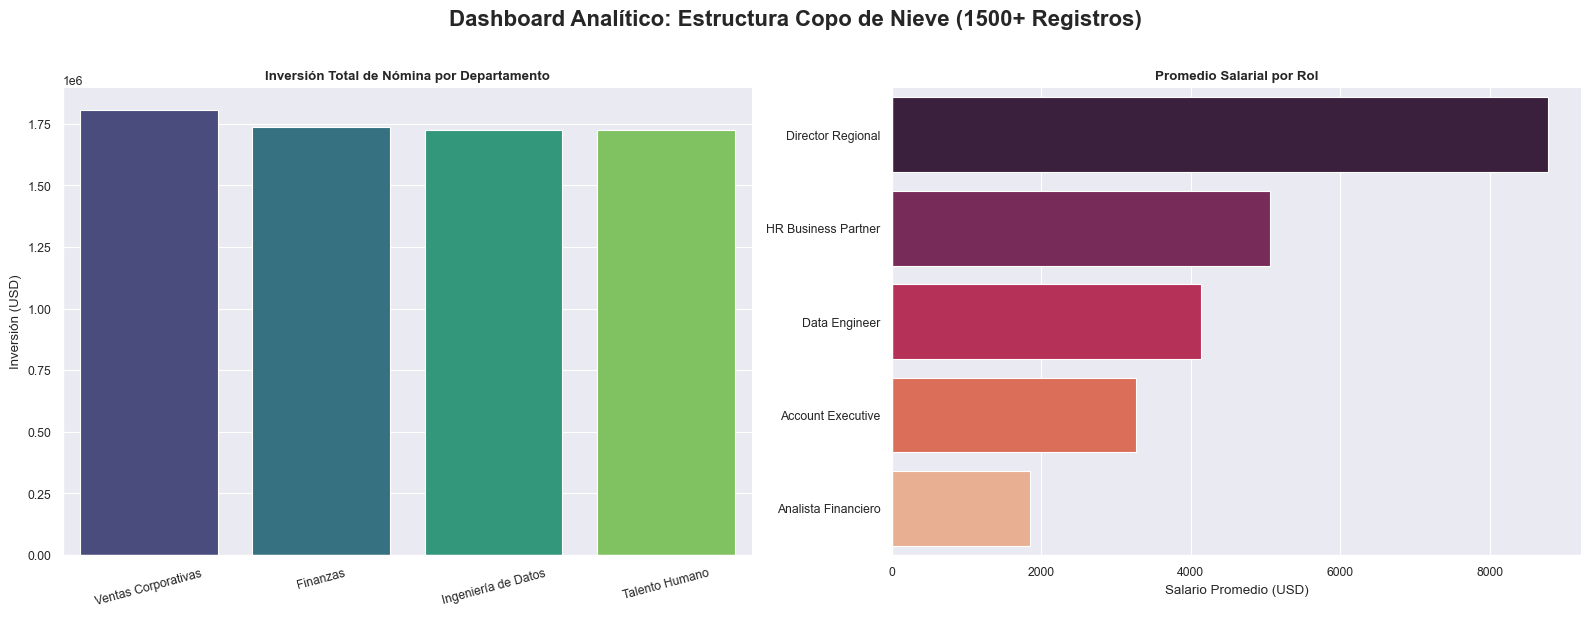

2026-05-21 23:08:53,075 - [BI_ENGINE] - INFO - Proceso analítico concluido exitosamente.


In [11]:
# -*- coding: utf-8 -*-
"""
Created on Thu May 21 22:18:06 2026

@author: jrodr
"""

# ==============================================================================
# Archivo: snowflake_bi_dashboard.py
# Arquitectura: Lee la Vista Optimizada, usa Pandas para formateo final y 
#               Seaborn para renderizar Dashboards Analíticos.
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------------------------
import pandas as pd                 # Estándar de la industria para manipulación de DataFrames.
from sqlalchemy import create_engine, exc # ORM para conexión segura a bases de datos relacionales.
import logging                      # Sistema de bitácoras para auditar la ejecución en producción.
import matplotlib.pyplot as plt       # Motor gráfico base.
import seaborn as sns               # Capa superior de matplotlib para gráficos estéticos y estadísticos.

# ------------------------------------------------------------------------------
# 2. CONFIGURACIÓN DEL SISTEMA DE LOGS (Trazabilidad)
# ------------------------------------------------------------------------------
# Usamos logger para guardar historial de ejecución.
logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s - [BI_ENGINE] - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# ------------------------------------------------------------------------------
# 3. CLASE DEL MOTOR DE BUSINESS INTELLIGENCE
# ------------------------------------------------------------------------------
class SnowflakeDashboard:
    
    # Método constructor: Configura la conexión a la BD al instanciar la clase
    def __init__(self, db_uri="mysql+pymysql://root:@localhost:3306/hr_snowflake_analytics"):
        self.engine = create_engine(db_uri) # Crea el motor de conexión de SQLAlchemy
        self.df_data = pd.DataFrame()       # Inicializa el DataFrame vacío de forma segura

    # --------------------------------------------------------------------------
    # MÉTODOS DE EXTRACCIÓN
    # --------------------------------------------------------------------------
    def fetch_analytical_view(self):
        """
        Se conecta a MySQL y extrae el resultado de la vista 'vw_snowflake_analisis'.
        Como la vista ya tiene CTEs y Window Functions.
        """
        logger.info("Iniciando conexión y extracción de datos desde MySQL...")
        try:
            # pd.read_sql ejecuta la consulta y convierte el resultado directamente a DataFrame
            self.df_data = pd.read_sql("SELECT * FROM vw_snowflake_analisis;", self.engine)
            logger.info(f"Éxito. Se extrajeron {len(self.df_data)} registros procesados.")
            
        except exc.SQLAlchemyError as e:
            # Si MySQL está apagado o la clave es incorrecta, capturamos el error aquí
            logger.critical(f"Error de conexión a la base de datos: {e}")
            raise

    # --------------------------------------------------------------------------
    # MÉTODOS DE TRANSFORMACIÓN EN MEMORIA Y CONSOLA
    # --------------------------------------------------------------------------
    def print_executive_summary(self):
        """
        Imprime un resumen de los requerimientos analíticos en la terminal.
        """
        # Validación de seguridad: no procesar si no hay datos
        if self.df_data.empty:
            logger.warning("El DataFrame está vacío. Asegúrate de ejecutar el SP en MySQL.")
            return

        print("\n" + "="*80)
        print("REPORTE GERENCIAL: RECURSOS HUMANOS (1500+ EMPLEADOS)".center(80))
        print("="*80)
        
        # Requerimiento: Promedio Salarial Global
        promedio_global = self.df_data['salario_neto'].mean()
        print(f"Salario Neto Promedio Global: ${promedio_global:,.2f}\n")

        # Requerimiento: Salarios por Región (Agrupación)
        print("GASTO SALARIAL POR REGIÓN:")
        # Agrupamos por región, sumamos el neto y ordenamos de mayor a menor
        kpi_region = self.df_data.groupby('nombre_region')['salario_neto'].sum().sort_values(ascending=False)
        # Formateamos los números a String con formato de moneda
        print(kpi_region.apply(lambda x: f"${x:,.2f}").to_string())
        print("-" * 80)

        # Requerimiento: Top 10 Empleados con Mayor Salario
        print("TOP 10 EMPLEADOS MEJOR PAGADOS (A nivel global):")
        # .nlargest es una función optimizada de pandas equivalente a ORDER BY DESC LIMIT 10
        top_10 = self.df_data.nlargest(10, 'salario_neto')[
            ['nombre_completo', 'nombre_puesto', 'nombre_departamento', 'salario_neto']
        ]
        # Imprimimos sin el índice numérico y aplicando formato al salario
        print(top_10.to_string(index=False, formatters={'salario_neto': lambda x: f"${x:,.2f}"}))
        print("="*80 + "\n")

    # --------------------------------------------------------------------------
    # MÉTODOS DE VISUALIZACIÓN (Capa Final)
    # --------------------------------------------------------------------------
    def render_dashboards(self):
        """
        Genera gráficos interactivos utilizando Seaborn y Matplotlib.
        """
        if self.df_data.empty: return
        
        logger.info("Generando gráficos y preparando el renderizado en pantalla...")
        
        # Configuramos el fondo oscuro profesional
        sns.set_theme(style="darkgrid", context="paper")
        
        # Creamos una figura dividida en 1 fila y 2 columnas
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Dashboard Analítico: Estructura Copo de Nieve (1500+ Registros)', 
                     fontsize=16, fontweight='bold', y=1.02)
        
        # -- GRÁFICO 1: Gasto Total por Departamento --
        # Agrupamos los datos
        gasto_depto = self.df_data.groupby('nombre_departamento')['salario_neto'].sum().reset_index()
        gasto_depto = gasto_depto.sort_values('salario_neto', ascending=False)
        
        # Renderizamos el gráfico de barras en la posición [0]
        sns.barplot(
            data=gasto_depto, x='nombre_departamento', y='salario_neto', 
            ax=axes[0], palette='viridis', hue='nombre_departamento', legend=False
        )
        axes[0].set_title('Inversión Total de Nómina por Departamento', fontweight='bold')
        axes[0].set_ylabel('Inversión (USD)')
        axes[0].set_xlabel('')
        axes[0].tick_params(axis='x', rotation=15) # Rotamos el texto del eje X 15 grados
        
        # -- GRÁFICO 2: Distribución de Salarios por Puesto --
        # Agrupamos calculando el promedio por cada puesto
        promedio_puesto = self.df_data.groupby('nombre_puesto')['salario_neto'].mean().reset_index()
        promedio_puesto = promedio_puesto.sort_values('salario_neto', ascending=False)
        
        # Renderizamos barras horizontales en la posición [1]
        sns.barplot(
            data=promedio_puesto, x='salario_neto', y='nombre_puesto', 
            ax=axes[1], palette='rocket', hue='nombre_puesto', legend=False
        )
        axes[1].set_title('Promedio Salarial por Rol', fontweight='bold')
        axes[1].set_xlabel('Salario Promedio (USD)')
        axes[1].set_ylabel('')
        
        # sns.despine() elimina los bordes superior y derecho del gráfico haciéndolo más limpio
        sns.despine()
        
        # Ajusta automáticamente los espaciados para evitar que los textos se superpongan
        plt.tight_layout()
        
        # Muestra la ventana de la interfaz gráfica
        plt.show()
        logger.info("Proceso analítico concluido exitosamente.")

# ==============================================================================
# PUNTO DE ENTRADA PRINCIPAL
# ==============================================================================
# Verifica que el script se está ejecutando directamente y no siendo importado
if __name__ == "__main__":
    
    # 1. Instanciamos nuestra clase principal
    dashboard = SnowflakeDashboard()
    
    try:
        # 2. Orquestamos la ejecución secuencial de los métodos
        dashboard.fetch_analytical_view()   # Conecta y extrae
        dashboard.print_executive_summary() # Analiza e imprime en consola
        dashboard.render_dashboards()       # Dibuja la interfaz visual
        
    except Exception as e:
        # 3. Captura global de errores: Si algo falla, el logger lo registra sin "romper" la consola brutalmente.
        logger.critical(f"La ejecución falló por el siguiente motivo: {e}")

# Requisitos de Instalación

## Dependencias

```bash
pip install pandas sqlalchemy pymysql matplotlib seaborn
```

---

# Ejecución del Proyecto

```bash
python snowflake_bi_dashboard.py
```

---

# Resultado Esperado

## Consola

- KPIs
- Rankings
- Resumen ejecutivo

## Dashboard

- Gráfico salarial por departamento
- Promedio salarial por puesto

---

# Conclusión

Este proyecto implementa una arquitectura analítica completa utilizando:

- Snowflake Schema
- SQL Analítico
- Pandas
- Seaborn
- Programación orientada a objetos

Todo ello siguiendo buenas prácticas de:

- BI
- Data Engineering
- Data Visualization
- Observabilidad
- Escalabilidad

---
## STAR vs Snowflake Schema

## Ejercicio Propuesto (Nicole)

Construir dos modelos analíticos:

1. STAR Schema.
2. Snowflake Schema.

Utilizando un mismo dataset empresarial.


### Requerimientos

1. Generar:
   - mínimo 5000 registros.

2. Construir:
   - dimensiones,
   - fact table.

3. Realizar:
   - KPIs,
   - agrupaciones,
   - análisis comparativos.

4. Medir:
   - tiempo de ejecución,
   - complejidad de consultas.

5. Analizar:
   - ventajas y desventajas de cada modelo.

## Base de datos

# Insert

# Consulta de verificación de datos - Resultados de referencia

## Estructura Conceptual

```text
                    DIM_CIUDADES
                           |
                           |
DIM_CLIENTES ----- DIM_REGIONES
        |
        |
        |------ FACT_VENTAS ------ DIM_PRODUCTOS ----- DIM_CATEGORIAS
        |
        |
   DIM_TIEMPO
```

In [5]:
# Reportes sql

In [6]:
# Codigo Python

# Conclusion